# Feature detection

## Harris Corner detection

As always we start with the imports

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

To start, we will use the same checkerboard image as earlier.

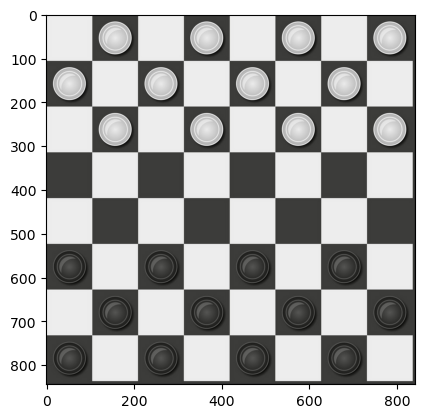

In [5]:
img = cv2.imread('checkers.png')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2a
Fill in the missing code in the next block. We would like to detect the corners of the image using the OpenCV function [`cv2.cornerHarris`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#gac1fc3598018010880e370e2f709b4345). Afterwards we want to draw the location of the detected corners on the image and display it.

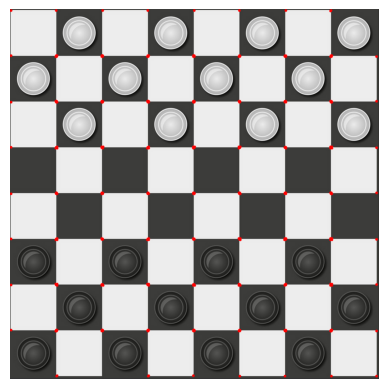

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
dst = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.14)

# Threshold for strong corners
threshold = 0.01 * dst.max()

# Make a copy to draw on
img_marked = img.copy()

# Draw small circles for all corners above threshold
corners_y, corners_x = np.where(dst > threshold)
for x, y in zip(corners_x, corners_y):
    cv2.circle(img_marked, (x, y), 3, (255, 0, 0), -1)  # filled red circle

plt.imshow(img_marked)
plt.axis('off')
plt.show()

## Shi-Tomasi
Next we will try the Shi-Tomasi feature detection method. In OpenCV, that method is implemented as [`cv2.goodFeaturesToTrack`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga1d6bb77486c8f92d79c8793ad995d541). 
Let's start with a different image this time.

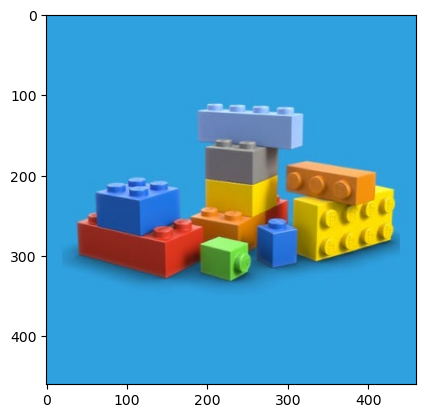

In [7]:
img = cv2.imread('Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2b
Just like the previous exercise, detect the corners of the image by inserting the missing code, this time using the Shi-Tomasi (good features to track) method. Draw the detected corners on the image. Check the documentation of the function for help.

In [8]:
img = cv2.imread('Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

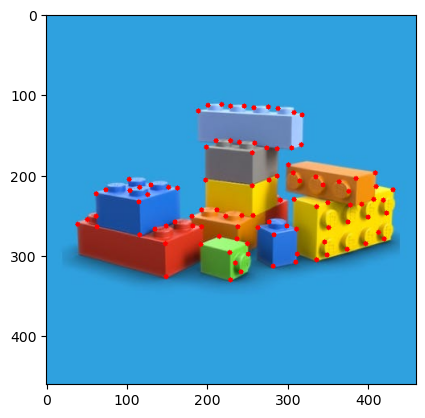

In [9]:
### Insert goodFeaturesToTrack detector here ###

corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = np.int32(corners)

for i in corners:
    x, y = i.ravel()
    cv2.circle(img, (x, y), 3, (255, 0, 0), -1)  

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

### Draw the detected corners in the original image here ###

# Display image
plt. imshow(img)

### Exercise 2c
Do a Harris corner detection on the same Lego image and compare the result with the Shi-Tomasi image.

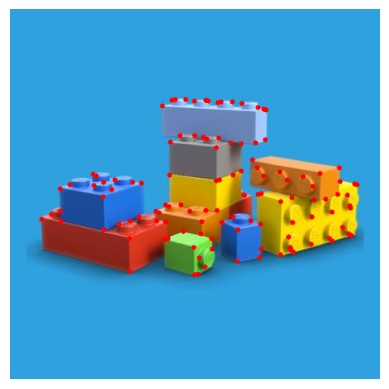

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
dst = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.14)

# Threshold for strong corners
threshold = 0.15 * dst.max()

# Make a copy to draw on
img_marked = img.copy()

# Draw small circles for all corners above threshold
corners_y, corners_x = np.where(dst > threshold)
for x, y in zip(corners_x, corners_y):
    cv2.circle(img_marked, (x, y), 3, (255, 0, 0), -1)  # filled red circle

plt.imshow(img_marked)
plt.axis('off')
plt.show()